In [1]:
#!/usr/bin/env python3
"""
LeRobot Episode Visualizer - Handle Dictionary Image Data
处理字典格式的图像数据
"""

import argparse
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button
import pyarrow.parquet as pq
import os
from pathlib import Path
import sys
from typing import Dict, List, Any, Optional, Union
import warnings

# 抑制警告
warnings.filterwarnings('ignore')

# 如果在Jupyter中运行，启用交互模式
try:
    from IPython.display import display, clear_output
    import ipywidgets as widgets
    IN_JUPYTER = True
except ImportError:
    IN_JUPYTER = False

class LeRobotEpisodeVisualizer:
    """LeRobot数据集episode可视化器 - 处理字典图像数据"""
    
    def __init__(self, dataset_path: str):
        """
        初始化可视化器
        
        Args:
            dataset_path: LeRobot数据集路径
        """
        self.dataset_path = Path(dataset_path)
        self.repo_id = self.dataset_path.name
        self.load_dataset_info()
        
    def load_dataset_info(self):
        """加载数据集信息"""
        # 加载info.json
        info_path = self.dataset_path / "meta" / "info.json"
        with open(info_path) as f:
            self.info = json.load(f)
        
        # 加载episodes.jsonl
        episodes_path = self.dataset_path / "meta" / "episodes.jsonl"
        self.episodes = []
        with open(episodes_path) as f:
            for line in f:
                self.episodes.append(json.loads(line))
        
        # 获取所有episode索引
        self.episode_indices = [ep["episode_index"] for ep in self.episodes]
        
        # 获取特征列表
        self.features = list(self.info.get("features", {}).keys())
        
        # 分类特征类型
        self.scalar_features = []  # 标量特征
        self.image_features = []   # 图像特征
        self.state_features = []   # 状态特征
        self.other_features = []   # 其他特征
        
        for feature in self.features:
            if '_rgb' in feature or feature.endswith('_image'):
                self.image_features.append(feature)
            elif feature in ['state', 'actions', 'observation', 'action']:
                self.state_features.append(feature)
            elif feature in ['binned_value', 'intervention', 'stage', 'is_good_action', 
                           'advantage', 'predicted_value', 'timestamp', 'frame_index',
                           'episode_index', 'index', 'task_index']:
                self.scalar_features.append(feature)
            else:
                self.other_features.append(feature)
        
        print(f"Dataset: {self.repo_id}")
        print(f"Episodes: {len(self.episodes)}")
        print(f"Scalar features: {len(self.scalar_features)}")
        print(f"Image features: {', '.join(self.image_features)}")
        print(f"State features: {len(self.state_features)}")
        
    def load_episode_data(self, episode_idx: int) -> tuple[Dict, Dict]:
        """加载指定episode的数据"""
        # 计算chunk索引
        chunks_size = self.info.get("chunks_size", 1000)
        chunk_idx = episode_idx // chunks_size
        
        # 构建parquet文件路径
        parquet_path = (
            self.dataset_path / "data" / f"chunk-{chunk_idx:03d}" / f"episode_{episode_idx:06d}.parquet"
        )
        
        if not parquet_path.exists():
            raise FileNotFoundError(f"Episode {episode_idx} not found: {parquet_path}")
        
        # 读取parquet文件
        table = pq.read_table(parquet_path)
        
        # 转换为numpy数组字典
        data = {}
        for col_name in table.column_names:
            col_data = table[col_name]
            
            # 特殊处理：检查是否是字典类型的图像数据
            if col_name in self.image_features:
                # 图像数据，尝试提取
                try:
                    # 尝试转换为list
                    data_list = col_data.to_pylist()
                    # 检查是否是字典列表
                    if data_list and isinstance(data_list[0], dict):
                        # 从字典中提取图像数据
                        extracted_images = []
                        for item in data_list:
                            if isinstance(item, dict) and 'bytes' in item:
                                # 从bytes重建图像
                                import io
                                from PIL import Image
                                img_bytes = item['bytes']
                                if isinstance(img_bytes, bytes):
                                    img = Image.open(io.BytesIO(img_bytes))
                                    img_array = np.array(img)
                                    extracted_images.append(img_array)
                                else:
                                    extracted_images.append(None)
                            elif isinstance(item, dict) and 'array' in item:
                                # 直接是数组
                                extracted_images.append(np.array(item['array']))
                            else:
                                extracted_images.append(None)
                        
                        # 过滤None值
                        valid_images = [img for img in extracted_images if img is not None]
                        if valid_images:
                            data[col_name] = np.array(valid_images)
                            print(f"Successfully extracted {len(valid_images)} images from {col_name}")
                        else:
                            data[col_name] = data_list
                    else:
                        # 尝试常规转换
                        np_data = col_data.to_numpy()
                        data[col_name] = np_data
                except Exception as e:
                    print(f"Warning: Could not extract images from {col_name}: {e}")
                    data[col_name] = col_data
            else:
                # 非图像数据，尝试常规转换
                try:
                    if hasattr(col_data, 'to_numpy'):
                        np_data = col_data.to_numpy()
                    else:
                        np_data = np.array(col_data)
                    
                    if isinstance(np_data, np.ndarray):
                        if np_data.ndim == 2 and np_data.shape[1] == 1:
                            np_data = np_data.squeeze(axis=1)
                        data[col_name] = np_data
                    else:
                        data[col_name] = np_data
                except:
                    data[col_name] = col_data
        
        # 获取episode信息
        episode_info = next(ep for ep in self.episodes if ep["episode_index"] == episode_idx)
        
        return data, episode_info
    
    def is_valid_scalar_data(self, data) -> bool:
        """检查数据是否是有效的标量数据"""
        if isinstance(data, np.ndarray):
            if data.dtype == object:
                return False
            if data.ndim == 1:
                return True
            if data.ndim == 2 and data.shape[1] == 1:
                return True
        return False
    
    def get_scalar_value(self, data) -> np.ndarray:
        """获取标量值，处理多维数据"""
        if not isinstance(data, np.ndarray):
            return np.array([0])
        
        if data.dtype == object:
            return np.zeros(1)
        
        if data.ndim == 1:
            return data
        elif data.ndim == 2 and data.shape[1] == 1:
            return data.squeeze()
        elif data.ndim == 2:
            return data[:, 0]  # 取第一维
        else:
            return np.zeros(len(data))
    
    def extract_image_from_dict(self, img_dict: Dict) -> Optional[np.ndarray]:
        """从字典中提取图像数据"""
        if not isinstance(img_dict, dict):
            return None
        
        try:
            if 'bytes' in img_dict:
                # 从bytes重建图像
                import io
                from PIL import Image
                img_bytes = img_dict['bytes']
                if isinstance(img_bytes, bytes):
                    img = Image.open(io.BytesIO(img_bytes))
                    return np.array(img)
            
            elif 'array' in img_dict:
                # 直接是数组
                array_data = img_dict['array']
                if isinstance(array_data, (list, np.ndarray)):
                    return np.array(array_data)
            
            elif 'path' in img_dict:
                # 文件路径
                img_path = Path(img_dict['path'])
                if img_path.exists():
                    from PIL import Image
                    img = Image.open(img_path)
                    return np.array(img)
            
            return None
            
        except Exception as e:
            print(f"Error extracting image from dict: {e}")
            return None
    
    def plot_scalar_features(self, data: Dict, ep_len: int, features_to_plot: List[str], 
                            ax: plt.Axes):
        """绘制标量特征曲线"""
        colors = plt.cm.tab10(np.linspace(0, 1, len(features_to_plot)))
        
        for i, feature in enumerate(features_to_plot):
            if feature in data:
                feature_data = data[feature]
                
                if self.is_valid_scalar_data(feature_data):
                    scalar_values = self.get_scalar_value(feature_data)
                    
                    if len(scalar_values) > 0:
                        # 归一化到[0,1]区间
                        if len(np.unique(scalar_values)) > 1:
                            normalized = (scalar_values - scalar_values.min()) / (scalar_values.max() - scalar_values.min() + 1e-8)
                        else:
                            normalized = np.zeros_like(scalar_values)
                        
                        # 偏移显示
                        y_offset = i * 1.0
                        x = np.arange(len(normalized))
                        ax.plot(x, normalized + y_offset, 'o-', markersize=2, 
                               color=colors[i], label=feature, alpha=0.7, linewidth=1)
        
        # 如果有stage特征，添加阶段背景
        if 'stage' in data and self.is_valid_scalar_data(data['stage']):
            stages = self.get_scalar_value(data['stage'])
            if len(stages) > 0:
                unique_stages = np.unique(stages)
                
                if len(unique_stages) > 0:
                    stage_colors = plt.cm.Set3(np.linspace(0, 1, len(unique_stages)))
                    
                    current_stage = stages[0]
                    start_idx = 0
                    
                    for j in range(1, len(stages)):
                        if stages[j] != current_stage:
                            color = stage_colors[int(current_stage) % len(stage_colors)]
                            ax.axvspan(start_idx, j, alpha=0.1, color=color)
                            current_stage = stages[j]
                            start_idx = j
                    
                    # 最后一个阶段
                    color = stage_colors[int(current_stage) % len(stage_colors)]
                    ax.axvspan(start_idx, len(stages), alpha=0.1, color=color)
        
        return ax
    
    def plot_images(self, data: Dict, timestep: int, axes: List[plt.Axes]):
        """绘制图像 - 处理字典格式的图像数据"""
        image_features = [f for f in self.image_features if f in data]
        
        for i, feature in enumerate(image_features):
            if i >= len(axes):
                break
                
            ax = axes[i]
            feature_data = data[feature]
            
            # 获取指定timestep的图像数据
            img_data = None
            
            if isinstance(feature_data, np.ndarray) and timestep < len(feature_data):
                # 已经是numpy数组
                img_data = feature_data[timestep]
            elif isinstance(feature_data, (list, np.ndarray)) and timestep < len(feature_data):
                # 列表或对象数组
                item = feature_data[timestep]
                if isinstance(item, dict):
                    # 从字典提取
                    img_data = self.extract_image_from_dict(item)
                elif isinstance(item, np.ndarray):
                    img_data = item
            
            if img_data is not None and isinstance(img_data, np.ndarray):
                # 处理图像数据
                if img_data.ndim == 3:
                    # 可能是CHW或HWC格式
                    if img_data.shape[0] in [1, 3]:  # CHW格式
                        # 转换为HWC
                        if img_data.shape[0] == 1:  # 单通道
                            img_data = img_data[0]  # 1xHxW -> HxW
                        else:  # 3通道
                            img_data = np.transpose(img_data, (1, 2, 0))  # CxHxW -> HxWxC
                
                # 确保值范围正确
                if img_data.dtype in [np.float32, np.float64]:
                    if img_data.max() <= 1.0:
                        img_data = (img_data * 255).astype(np.uint8)
                elif img_data.dtype == np.uint8:
                    pass
                elif img_data.dtype in [np.int16, np.int32, np.int64]:
                    # 归一化到0-255
                    img_min, img_max = img_data.min(), img_data.max()
                    if img_max > img_min:
                        img_data = ((img_data - img_min) / (img_max - img_min) * 255).astype(np.uint8)
                    else:
                        img_data = np.zeros_like(img_data, dtype=np.uint8)
                
                # 显示图像
                if img_data.ndim == 2:  # 灰度图
                    ax.imshow(img_data, cmap='gray', vmin=0, vmax=255)
                else:  # 彩色图
                    ax.imshow(img_data)
                
                ax.set_title(f'{feature} (t={timestep})', fontsize=10)
                ax.axis('off')
            else:
                # 无法显示图像
                ax.text(0.5, 0.5, f'No image data\nat t={timestep}', 
                       ha='center', va='center', transform=ax.transAxes)
                ax.set_title(f'{feature}', fontsize=10)
                ax.axis('off')
    
    def visualize_episode(self, episode_idx: int, timestep: int = 0, 
                         figsize: tuple = (20, 12)):
        """
        可视化episode的标量特征和指定timestep的图像
        
        Args:
            episode_idx: episode索引
            timestep: 要显示图像的timestep
            figsize: 图形大小
        """
        # 加载数据
        data, episode_info = self.load_episode_data(episode_idx)
        
        # 获取episode长度
        ep_len = 0
        for key, value in data.items():
            if hasattr(value, '__len__'):
                ep_len = max(ep_len, len(value))
                break
        
        # 创建图形
        fig = plt.figure(figsize=figsize)
        
        # 检查有多少图像特征
        image_features_in_data = [f for f in self.image_features if f in data]
        n_image_features = len(image_features_in_data)
        
        if n_image_features > 0:
            # 创建网格布局
            if n_image_features == 1:
                # 1个图像：左图右标量
                gs = fig.add_gridspec(1, 2, width_ratios=[1, 2])
                ax_scalar = fig.add_subplot(gs[0, 1])
                ax_img1 = fig.add_subplot(gs[0, 0])
                ax_img2 = None
            elif n_image_features == 2:
                # 2个图像：上标量，下两图
                gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])
                ax_scalar = fig.add_subplot(gs[0, :])
                ax_img1 = fig.add_subplot(gs[1, 0])
                ax_img2 = fig.add_subplot(gs[1, 1])
            else:  # 3个或更多图像
                # 上标量，下三图
                gs = fig.add_gridspec(2, 3, height_ratios=[1, 1])
                ax_scalar = fig.add_subplot(gs[0, :])
                ax_img1 = fig.add_subplot(gs[1, 0])
                ax_img2 = fig.add_subplot(gs[1, 1])
                ax_img3 = fig.add_subplot(gs[1, 2])
        else:
            # 只有标量特征
            gs = fig.add_gridspec(1, 1)
            ax_scalar = fig.add_subplot(gs[0, 0])
            ax_img1 = ax_img2 = None
        
        # 1. 绘制标量特征
        scalar_to_plot = [f for f in self.scalar_features if f in data]
        if scalar_to_plot:
            self.plot_scalar_features(data, ep_len, scalar_to_plot, ax_scalar)
            ax_scalar.set_xlabel('Timestep')
            ax_scalar.set_ylabel('Normalized Value (offset)')
            ax_scalar.set_title(f'Scalar Features - Episode {episode_idx}')
            ax_scalar.legend(loc='upper right', fontsize='small', ncol=2)
            ax_scalar.grid(True, alpha=0.3)
            ax_scalar.set_xlim(-1, ep_len)
            if scalar_to_plot:
                ax_scalar.set_ylim(-0.5, len(scalar_to_plot) + 0.5)
        
        # 2. 绘制图像
        if ax_img1 is not None:
            image_axes = [ax for ax in [ax_img1, ax_img2, ax_img3] if ax is not None]
            self.plot_images(data, timestep, image_axes)
        
        # 添加阶段统计信息
        if 'stage' in data and self.is_valid_scalar_data(data['stage']):
            stages = self.get_scalar_value(data['stage'])
            if len(stages) > 0:
                unique_stages, counts = np.unique(stages, return_counts=True)
                stage_info = ' | '.join([f'Stage {int(s)}: {c} frames ({c/len(stages)*100:.1f}%)' 
                                      for s, c in zip(unique_stages, counts)])
                
                # 添加阶段信息文本
                fig.text(0.5, 0.01, stage_info, ha='center', fontsize=10, 
                        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        # 添加总标题
        fig.suptitle(f'Episode {episode_idx} - Length: {ep_len} timesteps | Image at t={timestep}', 
                    fontsize=16, y=0.98)
        
        plt.tight_layout()
        return fig
    
    def create_image_grid(self, episode_idx: int, timesteps: List[int] = None, 
                         n_timesteps: int = 9, figsize: tuple = (20, 10)):
        """
        创建图像网格，显示多个timestep的图像
        
        Args:
            episode_idx: episode索引
            timesteps: 要显示的timestep列表，None则自动选择
            n_timesteps: 要显示的timestep数量
            figsize: 图形大小
        """
        # 加载数据
        data, episode_info = self.load_episode_data(episode_idx)
        
        # 获取episode长度
        ep_len = 0
        for key, value in data.items():
            if hasattr(value, '__len__'):
                ep_len = max(ep_len, len(value))
                break
        
        # 确定要显示的图像特征
        image_features = [f for f in self.image_features if f in data]
        if not image_features:
            print("No image features found in this episode")
            return None
        
        # 确定timesteps
        if timesteps is None:
            # 显示前n_timesteps个timestep
            n_timesteps = min(n_timesteps, ep_len)
            if ep_len <= n_timesteps:
                timesteps = list(range(ep_len))
            else:
                # 均匀采样
                step = max(1, ep_len // n_timesteps)
                timesteps = list(range(0, min(ep_len, n_timesteps * step), step))
                if len(timesteps) > n_timesteps:
                    timesteps = timesteps[:n_timesteps]
        
        n_rows = len(image_features)
        n_cols = len(timesteps)
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
        
        if n_rows == 1 and n_cols == 1:
            axes = [[axes]]
        elif n_rows == 1:
            axes = [axes]
        elif n_cols == 1:
            axes = [[ax] for ax in axes]
        
        for i, feature in enumerate(image_features):
            feature_data = data[feature]
            
            for j, timestep in enumerate(timesteps):
                if n_rows == 1:
                    ax = axes[j] if n_cols > 1 else axes
                elif n_cols == 1:
                    ax = axes[i]
                else:
                    ax = axes[i][j]
                
                if timestep < ep_len:
                    # 获取图像数据
                    img_data = None
                    
                    if isinstance(feature_data, np.ndarray):
                        img_data = feature_data[timestep]
                    elif isinstance(feature_data, (list, np.ndarray)) and timestep < len(feature_data):
                        item = feature_data[timestep]
                        if isinstance(item, dict):
                            img_data = self.extract_image_from_dict(item)
                        elif isinstance(item, np.ndarray):
                            img_data = item
                    
                    if img_data is not None and isinstance(img_data, np.ndarray):
                        # 处理图像显示
                        if img_data.ndim == 3 and img_data.shape[0] in [1, 3]:
                            if img_data.shape[0] == 1:
                                img_data = img_data[0]
                            else:
                                img_data = np.transpose(img_data, (1, 2, 0))
                        
                        if img_data.ndim == 2:
                            ax.imshow(img_data, cmap='gray')
                        else:
                            ax.imshow(img_data)
                        
                        ax.set_title(f't={timestep}', fontsize=8)
                        ax.axis('off')
                    else:
                        ax.text(0.5, 0.5, f'No image\nat t={timestep}', 
                               ha='center', va='center', transform=ax.transAxes, fontsize=8)
                        ax.axis('off')
                else:
                    ax.text(0.5, 0.5, f't={timestep}\n(Out of range)', 
                           ha='center', va='center', transform=ax.transAxes, fontsize=8)
                    ax.axis('off')
            
            # 在每行的第一个子图添加特征标签
            if n_cols > 0:
                if n_rows == 1:
                    ax_label = axes[0]
                elif n_cols == 1:
                    ax_label = axes[i]
                else:
                    ax_label = axes[i][0]
                
                ax_label.text(-0.3, 0.5, feature, transform=ax_label.transAxes,
                            ha='right', va='center', fontsize=10, fontweight='bold')
        
        fig.suptitle(f'Episode {episode_idx} - Image Grid ({len(timesteps)} timesteps)', 
                    fontsize=16, y=0.95)
        plt.tight_layout()
        return fig
    
    def summary_statistics(self, episode_idx: Optional[int] = None):
        """显示统计摘要"""
        if episode_idx is not None:
            # 单个episode统计
            data, episode_info = self.load_episode_data(episode_idx)
            
            print(f"\n{'='*60}")
            print(f"Episode {episode_idx} Statistics")
            print(f"{'='*60}")
            print(f"Length: {episode_info['length']} timesteps")
            print()
            
            # 标量特征统计
            print("Scalar Features:")
            print("-" * 40)
            scalar_features = [f for f in self.scalar_features if f in data]
            
            for feature in scalar_features:
                feature_data = data[feature]
                
                if self.is_valid_scalar_data(feature_data):
                    scalar_values = self.get_scalar_value(feature_data)
                    
                    if len(scalar_values) > 0:
                        print(f"\n{feature}:")
                        print(f"  Shape: {scalar_values.shape}")
                        print(f"  Min: {scalar_values.min():.4f}")
                        print(f"  Max: {scalar_values.max():.4f}")
                        print(f"  Mean: {scalar_values.mean():.4f}")
                        print(f"  Std: {scalar_values.std():.4f}")
                        
                        # 对于离散特征，显示值分布
                        if feature in ['binned_value', 'intervention', 'stage', 'is_good_action']:
                            unique, counts = np.unique(scalar_values, return_counts=True)
                            print(f"  Unique values: {len(unique)}")
                            for val, count in zip(unique, counts):
                                percentage = 100 * count / len(scalar_values)
                                print(f"    {val}: {count} frames ({percentage:.1f}%)")
                else:
                    print(f"\n{feature}: (non-scalar data)")
                    print(f"  Type: {type(feature_data)}")
                    if hasattr(feature_data, '__len__'):
                        print(f"  Length: {len(feature_data)}")
            
            # 图像特征统计
            print(f"\nImage Features:")
            print("-" * 40)
            image_features = [f for f in self.image_features if f in data]
            
            for feature in image_features:
                feature_data = data[feature]
                
                print(f"\n{feature}:")
                print(f"  Type: {type(feature_data)}")
                
                if hasattr(feature_data, '__len__'):
                    print(f"  Length: {len(feature_data)}")
                
                if isinstance(feature_data, (list, np.ndarray)) and len(feature_data) > 0:
                    # 检查第一个元素
                    first_item = feature_data[0]
                    print(f"  First item type: {type(first_item)}")
                    
                    if isinstance(first_item, dict):
                        print(f"  Keys: {list(first_item.keys())}")
                    elif isinstance(first_item, np.ndarray):
                        print(f"  Shape: {first_item.shape}")
                        print(f"  Dtype: {first_item.dtype}")
            
            # 状态特征统计
            print(f"\nState Features:")
            print("-" * 40)
            state_features = [f for f in self.state_features if f in data]
            
            for feature in state_features:
                feature_data = data[feature]
                
                if isinstance(feature_data, np.ndarray) and feature_data.ndim == 2:
                    print(f"\n{feature}:")
                    print(f"  Shape: {feature_data.shape}")
                    if feature_data.shape[1] <= 10:
                        print(f"  Mean per dimension: {feature_data.mean(axis=0)}")
                        print(f"  Std per dimension: {feature_data.std(axis=0)}")
                    else:
                        print(f"  Mean (first 5): {feature_data.mean(axis=0)[:5]}...")
                        print(f"  Std (first 5): {feature_data.std(axis=0)[:5]}...")
                elif hasattr(feature_data, '__len__'):
                    print(f"\n{feature}:")
                    print(f"  Length: {len(feature_data)}")
                    print(f"  Type: {type(feature_data)}")
                
        else:
            # 整个数据集统计
            print(f"\n{'='*60}")
            print(f"Dataset {self.repo_id} Statistics")
            print(f"{'='*60}")
            print(f"Total episodes: {len(self.episodes)}")
            
            # 统计episode长度
            lengths = [ep["length"] for ep in self.episodes]
            print(f"Episode lengths: min={min(lengths)}, max={max(lengths)}, mean={np.mean(lengths):.1f}")

def create_jupyter_widgets(visualizer):
    """为Jupyter Notebook创建交互式widgets"""
    
    # 创建episode选择器
    episode_selector = widgets.Dropdown(
        options=visualizer.episode_indices,
        value=visualizer.episode_indices[0] if visualizer.episode_indices else 0,
        description='Episode:',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='200px')
    )
    
    # 创建timestep滑块
    timestep_slider = widgets.IntSlider(
        value=0,
        min=0,
        max=100,
        step=1,
        description='Image Timestep:',
        continuous_update=False,
        layout=widgets.Layout(width='400px')
    )
    
    # 创建标量特征选择器
    scalar_checkboxes = []
    important_features = ['stage', 'binned_value', 'intervention']
    for feature in visualizer.scalar_features:
        # 默认选中重要特征
        default_value = feature in important_features
        checkbox = widgets.Checkbox(
            value=default_value,
            description=feature,
            disabled=False,
            indent=False,
            layout=widgets.Layout(width='150px')
        )
        scalar_checkboxes.append((feature, checkbox))
    
    # 创建动作按钮
    plot_button = widgets.Button(
        description="Visualize Episode",
        button_style='primary',
        layout=widgets.Layout(width='180px')
    )
    
    summary_button = widgets.Button(
        description="Show Summary",
        layout=widgets.Layout(width='180px')
    )
    
    image_grid_button = widgets.Button(
        description="Show Image Grid",
        button_style='info',
        layout=widgets.Layout(width='180px')
    )
    
    # 输出区域
    output = widgets.Output()
    
    def update_timestep_slider(episode_idx):
        """更新timestep滑块的最大值"""
        try:
            data, episode_info = visualizer.load_episode_data(episode_idx)
            ep_len = episode_info['length']
            timestep_slider.max = max(0, ep_len - 1)
            timestep_slider.value = min(timestep_slider.value, ep_len - 1)
        except Exception as e:
            print(f"Error updating slider: {e}")
    
    def on_plot_button_clicked(b):
        with output:
            clear_output(wait=True)
            episode_idx = episode_selector.value
            timestep = timestep_slider.value
            
            # 更新滑块
            update_timestep_slider(episode_idx)
            
            # 可视化
            fig = visualizer.visualize_episode(episode_idx, timestep)
            if fig:
                plt.show()
    
    def on_summary_button_clicked(b):
        with output:
            clear_output(wait=True)
            episode_idx = episode_selector.value
            visualizer.summary_statistics(episode_idx)
    
    def on_image_grid_clicked(b):
        with output:
            clear_output(wait=True)
            episode_idx = episode_selector.value
            
            # 显示图像网格
            fig = visualizer.create_image_grid(episode_idx, n_timesteps=9)
            if fig:
                plt.show()
    
    # 连接按钮事件
    plot_button.on_click(on_plot_button_clicked)
    summary_button.on_click(on_summary_button_clicked)
    image_grid_button.on_click(on_image_grid_clicked)
    
    # Episode选择器变化时更新滑块
    episode_selector.observe(lambda change: update_timestep_slider(change['new']), 'value')
    
    # 创建界面布局
    # 控制区域
    control_box = widgets.VBox([
        widgets.HBox([episode_selector]),
        timestep_slider,
        widgets.HBox([plot_button, summary_button, image_grid_button])
    ])
    
    # 标量特征选择区域
    scalar_grid = widgets.GridBox(
        [cb for _, cb in scalar_checkboxes],
        layout=widgets.Layout(
            grid_template_columns="repeat(4, 150px)",
            overflow='auto',
            height='150px',
            border='1px solid #ddd',
            padding='5px'
        )
    )
    
    scalar_box = widgets.VBox([
        widgets.Label("Scalar Features to display:", style={'font_weight': 'bold'}),
        scalar_grid
    ])
    
    # 主界面
    main_ui = widgets.VBox([
        control_box,
        scalar_box,
        output
    ])
    
    # 初始更新
    update_timestep_slider(episode_selector.value)
    
    return main_ui

def main():
    """命令行主函数"""
    parser = argparse.ArgumentParser(description='LeRobot Episode Visualizer - Handle Dictionary Images')
    parser.add_argument('dataset_path', type=str, help='Path to LeRobot dataset directory')
    parser.add_argument('--episode', type=int, default=0, help='Episode index to visualize')
    parser.add_argument('--timestep', type=int, default=0, help='Timestep to display images at')
    parser.add_argument('--summary', action='store_true', help='Show summary statistics')
    parser.add_argument('--image-grid', action='store_true', help='Show image grid')
    parser.add_argument('--grid-timesteps', type=int, default=9, help='Number of timesteps in grid')
    parser.add_argument('--interactive', action='store_true', help='Launch interactive GUI')
    
    args = parser.parse_args()
    
    # 创建可视化器
    visualizer = LeRobotEpisodeVisualizer(args.dataset_path)
    
    if args.interactive:
        if IN_JUPYTER:
            print("Running in Jupyter Notebook mode")
            ui = create_jupyter_widgets(visualizer)
            display(ui)
        else:
            print("Interactive mode requires Jupyter Notebook.")
            print("Use command line arguments for basic visualization.")
    
    elif args.image_grid:
        # 显示图像网格
        fig = visualizer.create_image_grid(args.episode, n_timesteps=args.grid_timesteps)
        if fig:
            plt.show()
    
    elif args.summary:
        # 显示统计摘要
        visualizer.summary_statistics(args.episode)
    
    else:
        # 可视化单个episode
        fig = visualizer.visualize_episode(args.episode, args.timestep)
        if fig:
            plt.show()

if __name__ == "__main__":
    # 如果在Jupyter中直接导入，不运行main()
    if __name__ == "__main__" and not IN_JUPYTER:
        main()

In [3]:
dataset_path = "/data/kding/Openpi_RL/lerobot_data/Fold_clothes_test"
visualizer = LeRobotEpisodeVisualizer(dataset_path)
ui = create_jupyter_widgets(visualizer)
display(ui)

Dataset: Fold_clothes_test
Episodes: 1
Scalar features: 6
Image features: base_0_rgb, left_wrist_0_rgb, right_wrist_0_rgb
State features: 2
Successfully extracted 1563 images from base_0_rgb
Successfully extracted 1563 images from left_wrist_0_rgb
Successfully extracted 1563 images from right_wrist_0_rgb


In [ ]:
def plot_action_vs_state(visualizer, episode_idx: int, figsize=(24, 28)):
    """Plot all 14 dimensions of action vs state, plus their delta, for a given episode.

    Layout: 14 rows x 2 cols
      - Left column: action (blue) and state (orange) overlaid
      - Right column: delta = action - state (green)
    """
    data, episode_info = visualizer.load_episode_data(episode_idx)
    state_raw = data.get("state")
    actions_raw = data.get("actions")

    if state_raw is None or actions_raw is None:
        print("Missing 'state' or 'actions' in episode data")
        return

    # Handle object arrays (parquet stores each row as a list)
    if isinstance(state_raw, np.ndarray) and state_raw.dtype == object:
        state = np.stack([np.asarray(x, dtype=np.float64) for x in state_raw])
    else:
        state = np.asarray(state_raw, dtype=np.float64)

    if isinstance(actions_raw, np.ndarray) and actions_raw.dtype == object:
        actions = np.stack([np.asarray(x, dtype=np.float64) for x in actions_raw])
    else:
        actions = np.asarray(actions_raw, dtype=np.float64)

    if state.ndim == 1:
        state = state.reshape(-1, 1)
    if actions.ndim == 1:
        actions = actions.reshape(-1, 1)

    n_dims = min(state.shape[1], actions.shape[1])
    T = min(len(state), len(actions))
    state = state[:T]
    actions = actions[:T]
    delta = actions[:, :n_dims] - state[:, :n_dims]

    dim_names = [
        "L_joint_1", "L_joint_2", "L_joint_3", "L_joint_4", "L_joint_5", "L_joint_6", "L_gripper",
        "R_joint_1", "R_joint_2", "R_joint_3", "R_joint_4", "R_joint_5", "R_joint_6", "R_gripper",
    ]
    if n_dims > len(dim_names):
        dim_names += [f"dim_{i}" for i in range(len(dim_names), n_dims)]

    fig, axes = plt.subplots(n_dims, 2, figsize=figsize, sharex=True)
    if n_dims == 1:
        axes = axes.reshape(1, -1)

    timesteps = np.arange(T)

    for d in range(n_dims):
        name = dim_names[d] if d < len(dim_names) else f"dim_{d}"

        # Left: action vs state
        ax_left = axes[d, 0]
        ax_left.plot(timesteps, state[:, d], color="tab:orange", linewidth=0.8, alpha=0.8, label="state")
        ax_left.plot(timesteps, actions[:, d], color="tab:blue", linewidth=0.8, alpha=0.8, label="action")
        ax_left.set_ylabel(name, fontsize=9)
        ax_left.grid(True, alpha=0.3)
        if d == 0:
            ax_left.set_title("Action (blue) vs State (orange)", fontsize=11)
            ax_left.legend(fontsize=8, loc="upper right")

        # Right: delta
        ax_right = axes[d, 1]
        ax_right.plot(timesteps, delta[:, d], color="tab:green", linewidth=0.8, alpha=0.8)
        ax_right.axhline(0, color="gray", linewidth=0.5, linestyle="--")
        ax_right.grid(True, alpha=0.3)
        if d == 0:
            ax_right.set_title("Delta (action - state)", fontsize=11)

        # Show mean delta on right axis
        mean_d = delta[:, d].mean()
        std_d = delta[:, d].std()
        ax_right.text(0.98, 0.92, f"mean={mean_d:.4f}\nstd={std_d:.4f}",
                      transform=ax_right.transAxes, fontsize=7,
                      ha="right", va="top",
                      bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))

    axes[-1, 0].set_xlabel("Timestep")
    axes[-1, 1].set_xlabel("Timestep")
    fig.suptitle(f"Episode {episode_idx}  —  Action vs State  (len={T})", fontsize=14, y=1.0)
    plt.tight_layout()
    plt.show()


# --- Visualize a specific episode ---
EPISODE_IDX = 0  # <-- change this to inspect different episodes
plot_action_vs_state(visualizer, EPISODE_IDX)

Successfully extracted 2066 images from base_0_rgb
Successfully extracted 2066 images from left_wrist_0_rgb
Successfully extracted 2066 images from right_wrist_0_rgb
Successfully extracted 2953 images from base_0_rgb
Successfully extracted 2953 images from left_wrist_0_rgb
Successfully extracted 2953 images from right_wrist_0_rgb
Analyzed 100 chunks (chunk_size=50) from 2 episodes, 14 dims



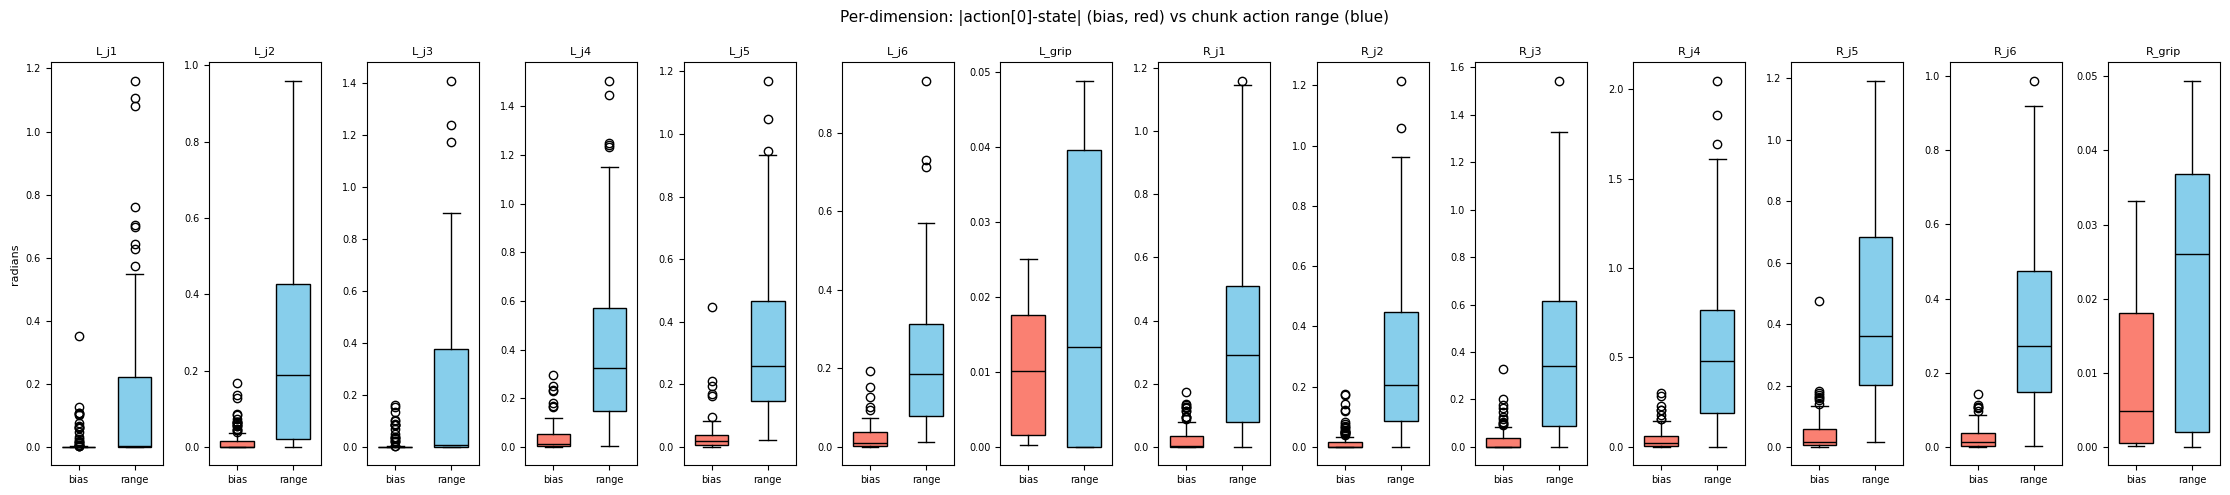

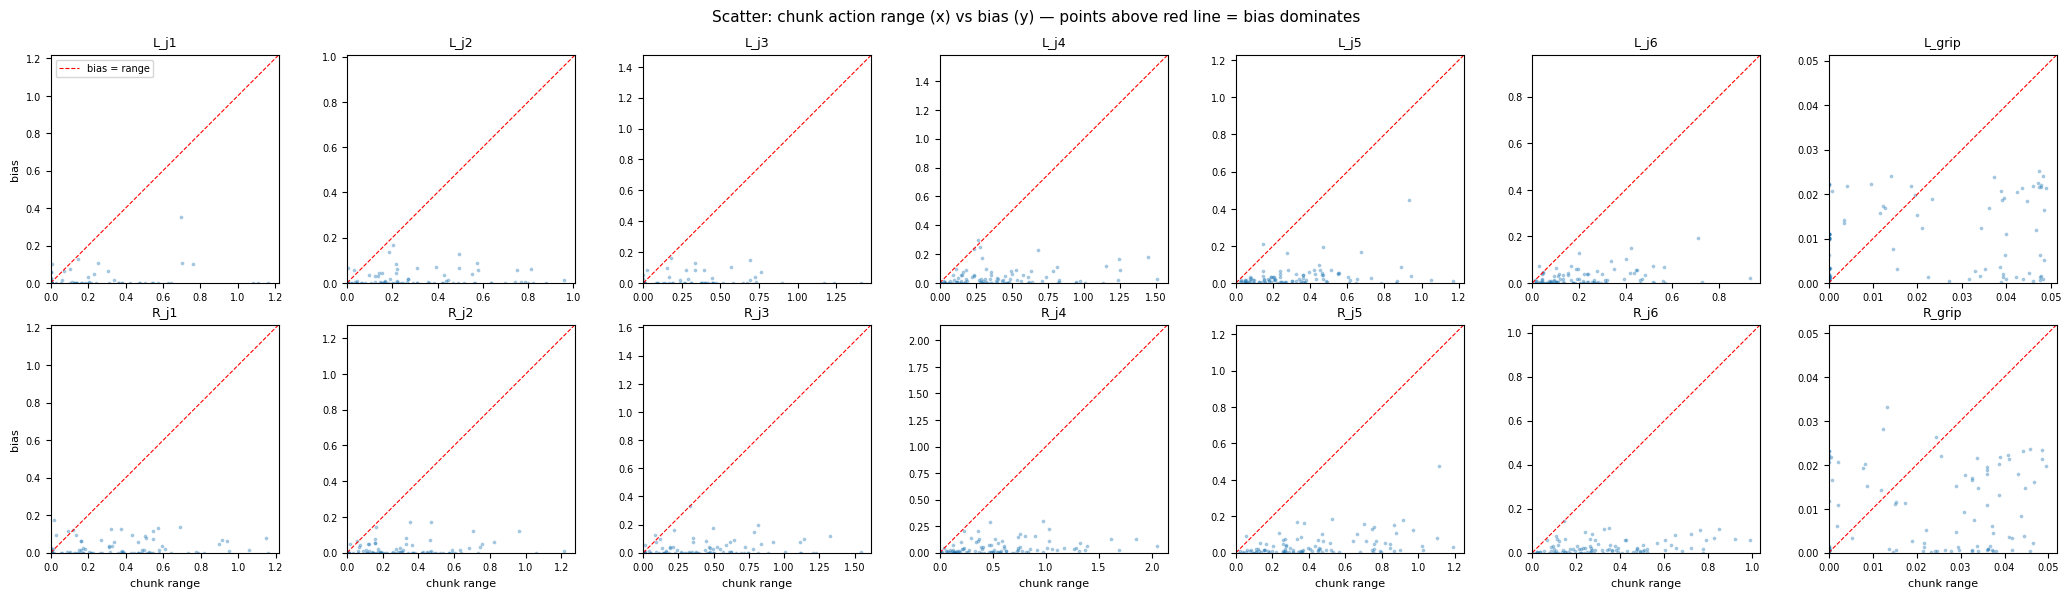

dim       median_bias  median_range  ratio(b/r)   % bias>range
--------------------------------------------------------------
L_j1          0.00076       0.00267        0.29          24.0%
L_j2          0.00114       0.18845        0.01          14.0%
L_j3          0.00076       0.00687        0.11          14.0%
L_j4          0.01354       0.32311        0.04           1.0%
L_j5          0.01812       0.25940        0.07           1.0%
L_j6          0.00973       0.18616        0.05           3.0%
L_grip        0.01013       0.01334        0.76          53.0%
R_j1          0.00229       0.29107        0.01          17.0%
R_j2          0.00114       0.20657        0.01          12.0%
R_j3          0.00191       0.34123        0.01          12.0%
R_j4          0.02232       0.48276        0.05           2.0%
R_j5          0.01736       0.36069        0.05           1.0%
R_j6          0.01450       0.27276        0.05           0.0%
R_grip        0.00495       0.02601        0.19        

In [3]:
def analyze_bias_vs_chunk_signal(visualizer, episode_indices=None, chunk_size=50, n_sample_eps=50):
    """Analyze whether the action-state bias dominates the within-chunk signal.

    For each chunk of `chunk_size` consecutive steps starting at timestep t:
      - bias[d]        = |action[t, d] - state[t, d]|           (instant offset at chunk start)
      - chunk_range[d] = max(action[t:t+C, d]) - min(action[t:t+C, d])  (how much action moves within chunk)

    If bias >> chunk_range, then the delta representation is dominated by a
    constant offset rather than meaningful motion — which is problematic.

    Produces:
      1. Per-dimension box plot comparing bias vs chunk_range across all chunks
      2. Per-dimension scatter: x = chunk_range, y = bias, with y=x reference line
      3. Summary table printed to stdout
    """
    import random

    def _to_float_array(raw):
        if isinstance(raw, np.ndarray) and raw.dtype == object:
            return np.stack([np.asarray(x, dtype=np.float64) for x in raw])
        return np.asarray(raw, dtype=np.float64)

    all_episodes = episode_indices or visualizer.episode_indices
    if len(all_episodes) > n_sample_eps:
        all_episodes = sorted(random.sample(list(all_episodes), n_sample_eps))

    dim_names = [
        "L_j1", "L_j2", "L_j3", "L_j4", "L_j5", "L_j6", "L_grip",
        "R_j1", "R_j2", "R_j3", "R_j4", "R_j5", "R_j6", "R_grip",
    ]

    # Collect per-chunk statistics
    all_bias = []       # (N_chunks, D)
    all_range = []      # (N_chunks, D)

    for ep_idx in all_episodes:
        data, _ = visualizer.load_episode_data(ep_idx)
        state = _to_float_array(data["state"])
        actions = _to_float_array(data["actions"])
        if state.ndim == 1:
            state = state.reshape(-1, 1)
        if actions.ndim == 1:
            actions = actions.reshape(-1, 1)
        n_dims = min(state.shape[1], actions.shape[1])
        T = min(len(state), len(actions))

        for t in range(0, T - chunk_size + 1, chunk_size):
            chunk_actions = actions[t : t + chunk_size, :n_dims]   # (C, D)
            state_t = state[t, :n_dims]                             # (D,)

            bias = np.abs(chunk_actions[0] - state_t)               # (D,)
            chunk_rng = chunk_actions.max(axis=0) - chunk_actions.min(axis=0)  # (D,)
            all_bias.append(bias)
            all_range.append(chunk_rng)

    all_bias = np.array(all_bias)    # (N, D)
    all_range = np.array(all_range)  # (N, D)
    N, D = all_bias.shape

    print(f"Analyzed {N} chunks (chunk_size={chunk_size}) from {len(all_episodes)} episodes, {D} dims\n")

    # ---- Figure 1: box plot comparison ----
    fig1, axes1 = plt.subplots(1, D, figsize=(D * 1.6, 5), sharey=False)
    if D == 1:
        axes1 = [axes1]
    for d in range(D):
        ax = axes1[d]
        bp = ax.boxplot(
            [all_bias[:, d], all_range[:, d]],
            labels=["bias", "range"],
            widths=0.6,
            patch_artist=True,
            medianprops=dict(color="black"),
        )
        bp["boxes"][0].set_facecolor("salmon")
        bp["boxes"][1].set_facecolor("skyblue")
        name = dim_names[d] if d < len(dim_names) else f"d{d}"
        ax.set_title(name, fontsize=8)
        ax.tick_params(labelsize=7)
        if d == 0:
            ax.set_ylabel("radians", fontsize=8)
    fig1.suptitle("Per-dimension: |action[0]-state| (bias, red) vs chunk action range (blue)", fontsize=11)
    plt.tight_layout()
    plt.show()

    # ---- Figure 2: scatter bias vs range ----
    n_cols = 7
    n_rows = (D + n_cols - 1) // n_cols
    fig2, axes2 = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
    axes2 = np.atleast_2d(axes2)
    for d in range(D):
        ax = axes2[d // n_cols, d % n_cols]
        ax.scatter(all_range[:, d], all_bias[:, d], s=3, alpha=0.3, c="tab:blue")
        lim = max(all_range[:, d].max(), all_bias[:, d].max()) * 1.05
        ax.plot([0, lim], [0, lim], "r--", linewidth=0.8, label="bias = range")
        ax.set_xlim(0, lim)
        ax.set_ylim(0, lim)
        ax.set_aspect("equal")
        name = dim_names[d] if d < len(dim_names) else f"d{d}"
        ax.set_title(name, fontsize=9)
        ax.tick_params(labelsize=7)
        if d % n_cols == 0:
            ax.set_ylabel("bias", fontsize=8)
        if d // n_cols == n_rows - 1:
            ax.set_xlabel("chunk range", fontsize=8)
        if d == 0:
            ax.legend(fontsize=7)
    # Hide unused subplots
    for d in range(D, n_rows * n_cols):
        axes2[d // n_cols, d % n_cols].set_visible(False)
    fig2.suptitle("Scatter: chunk action range (x) vs bias (y) — points above red line = bias dominates", fontsize=11)
    plt.tight_layout()
    plt.show()

    # ---- Summary table ----
    print(f"{'dim':<8} {'median_bias':>12} {'median_range':>13} {'ratio(b/r)':>11}  {'% bias>range':>13}")
    print("-" * 62)
    for d in range(D):
        mb = np.median(all_bias[:, d])
        mr = np.median(all_range[:, d])
        ratio = mb / mr if mr > 1e-9 else float("inf")
        pct = 100.0 * np.mean(all_bias[:, d] > all_range[:, d])
        name = dim_names[d] if d < len(dim_names) else f"d{d}"
        flag = " ⚠" if ratio > 1.0 else ""
        print(f"{name:<8} {mb:>12.5f} {mr:>13.5f} {ratio:>11.2f}  {pct:>12.1f}%{flag}")


analyze_bias_vs_chunk_signal(visualizer, chunk_size=50, n_sample_eps=2)